<a href="https://colab.research.google.com/github/OtolaHan/Otola_Han_KAAN/blob/main/Lab_M_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1. Введение в PyTorch. Полносвязные нейронные сети.

### Общая информация

Дата выдачи: 01.10.2023

Мягкий дедлайн: 23:59MSK 15.10.2023

Жесткий дедлайн: 23:59MSK 20.10.2023

### Оценивание и штрафы
Максимально допустимая оценка за работу — 10 баллов. За каждый день просрочки снимается 1 балл. Сдавать задание после жёсткого дедлайна сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.
Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как
$$
min(task_1, task_2)*0.8 + max(task_1, task_2)*0.2
$$

где task_1 и task_2 - оценки за первое и второе заданиее соответсвенно.
Также, за домашнее задание выставляется 0, если не сделано нулевое или третье задание.
### О задании

В этом задании вам предстоит предсказывать год выпуска песни (**задача регрессии**) по некоторым звуковым признакам: [данные](https://archive.ics.uci.edu/ml/datasets/yearpredictionmsd). В ячейках ниже находится код для загрузки данных. Обратите внимание, что обучающая и тестовая выборки располагаются в одном файле, поэтому НЕ меняйте ячейку, в которой производится деление данных.

In [25]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import random
device = "cuda" if torch.cuda.is_available() else "cpu"
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [26]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-03-04 13:07:05--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [    <=>             ] 201.24M  24.2MB/s    in 23s     

2025-03-04 13:07:27 (8.93 MB/s) - ‘data.txt.zip’ saved [211011981]



In [27]:
df = pd.read_csv('data.txt.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Мы вывели кусок данных, чтобы понять, насколько они пригодны для работы без изменений. Здесь ясно, что сомнительно дальше с такими данными работать, потому что как минимум есть отрицательные значения, которые не отмасштабированы, кроме того еще сразу бросается в глаза совсем разная размерность, где-то видим реально большие числа, а где-то 0.075. Ясно, что будем скейлить.

In [31]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = 463715
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

## Задание 0. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Для самого первого бейзлайна обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями
2. Обучите StandertScaler и предобработайте ваши данные. В следующих заданиях можете использовать другой scaler или вообще отказаться от него


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [33]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
set_random_seed(42)

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Обучение Ridge регрессии
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test_scaled)

# Вычисление RMSE для Ridge регрессии
rmse_for_model = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE для Ridge регрессии: {rmse_for_model}")

# Наилучший константный прогноз (среднее значение)
best_constant = np.mean(y_train)
y_pred_constant = np.full_like(y_test, best_constant)

RMSE для Ridge регрессии: 9.510160820470436


Лучшая константа для RMSE это среднее, посчитаем значение метрики при нем

In [36]:
best_rmse_metric = np.sqrt(mean_squared_error(y_test, y_pred_constant))
print(f"RMSE для наилучшего константного прогноза: {best_rmse_metric}")

RMSE для наилучшего константного прогноза: 10.863228020678134


## Задание 1. (максимум 10 баллов)

Закрепите свои знания о том, как pytorch работает с обратным распространением ошибки, проделав следующие шаги:

1. Создайте модель линейной регрессии, которая будет состоять только из одного Linear слоя.
2. Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки pytorch. Для подсчета градиента воспользуйтесь методом backward.
3. Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
4. Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача - убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

Epoch 1/10, Train Loss: 3993578.5000, Test Loss: 3835850.7500, Test RMSE: 1958.5328
Epoch 2/10, Train Loss: 3835435.5000, Test Loss: 3683947.0000, Test RMSE: 1919.3611
Epoch 3/10, Train Loss: 3683555.5000, Test Loss: 3538060.2500, Test RMSE: 1880.9733
Epoch 4/10, Train Loss: 3537689.7500, Test Loss: 3397951.5000, Test RMSE: 1843.3533
Epoch 5/10, Train Loss: 3397600.7500, Test Loss: 3263392.0000, Test RMSE: 1806.4861
Epoch 6/10, Train Loss: 3263059.2500, Test Loss: 3134161.7500, Test RMSE: 1770.3564
Epoch 7/10, Train Loss: 3133846.0000, Test Loss: 3010050.0000, Test RMSE: 1734.9496
Epoch 8/10, Train Loss: 3009749.0000, Test Loss: 2890852.7500, Test RMSE: 1700.2507
Epoch 9/10, Train Loss: 2890566.7500, Test Loss: 2776377.5000, Test RMSE: 1666.2466
Epoch 10/10, Train Loss: 2776104.0000, Test Loss: 2666435.2500, Test RMSE: 1632.9224


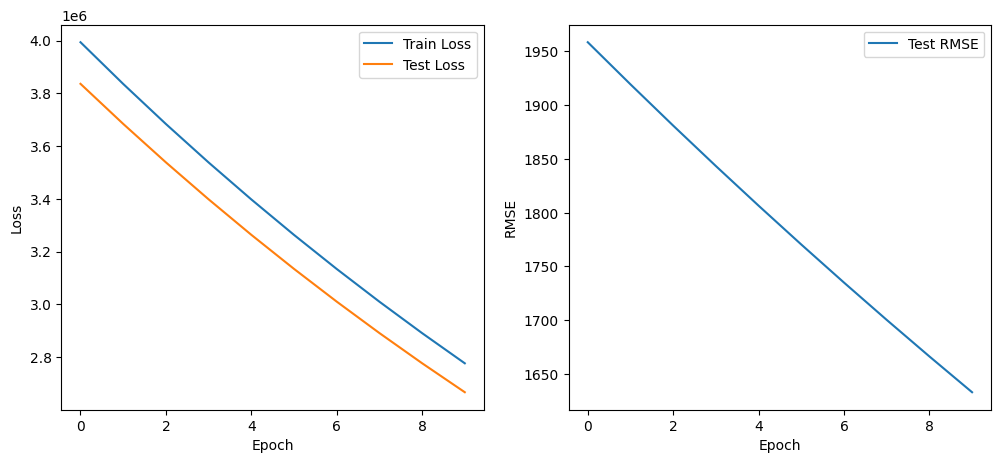

In [38]:
# Зафиксируем random_seed
def set_random_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(42)

# Создаем модель линейной регрессии
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)  # Один Linear слой

    def forward(self, x):
        return self.linear(x)

# Подготовка данных
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Инициализация модели
input_dim = X_train_tensor.shape[1]
model = LinearRegression(input_dim)

# Гиперпараметры
learning_rate = 0.01
epochs = 10

# Цикл обучения
train_losses = []
test_losses = []
test_metrics = []

for epoch in range(epochs):
    # Обучение
    model.train()
    y_pred = model(X_train_tensor)
    loss = torch.mean((y_pred - y_train_tensor) ** 2)  # MSE вручную
    loss.backward()  # Обратное распространение
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad  # Шаг градиентного спуска
        model.zero_grad()  # Обнуляем градиенты

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        test_loss = torch.mean((y_test_pred - y_test_tensor) ** 2)
        test_rmse = torch.sqrt(test_loss)

    # Сохраняем результаты
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    test_metrics.append(test_rmse.item())

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Test RMSE: {test_rmse.item():.4f}")

# Графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_metrics, label="Test RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## Задание 2. (максимум 10 баллов)

Реализуйте обучение и тестирование нейронной сети для предоставленного вам набора данных. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 9.00 $ &mdash; 4 балла
- $\text{RMSE} \le 8.90 $ &mdash; 6 баллов
- $\text{RMSE} \le 8.80 $ &mdash; 8 баллов
- $\text{RMSE} \le 8.75 $ &mdash; 10 баллов

Есть несколько правил, которых вам нужно придерживаться:

- Весь пайплайн обучения должен быть написан на PyTorch. При этом вы можете пользоваться другими библиотеками (`numpy`, `sklearn` и пр.), но только для обработки данных. То есть как угодно трансформировать данные и считать метрики с помощью этих библиотек можно, а импортировать модели из `sklearn` и выбивать с их помощью требуемое качество &mdash; нельзя. Также нельзя пользоваться библиотеками, для которых сам PyTorch является зависимостью.

- Мы никак не ограничиваем ваш выбор архитектуры модели, но скорее всего вам будет достаточно полносвязной нейронной сети.

- Для обучения запрещается использовать какие-либо иные данные, кроме обучающей выборки.

- Ансамблирование моделей запрещено.

### Полезные советы:

- Очень вряд ли, что у вас с первого раза получится выбить качество на 10 баллов, поэтому пробуйте разные архитектуры, оптимизаторы и значения гиперпараметров. В идеале при запуске каждого нового эксперимента вы должны менять что-то одно, чтобы точно знать, как этот фактор влияет на качество.

- Не забудьте, что для улучшения качества модели вам поможет **нормировка таргета**.

- Тот факт, что мы занимаемся глубинным обучением, не означает, что стоит забывать про приемы, использующиеся в классическом машинном обучении. Так что обязательно проводите исследовательский анализ данных, отрисовывайте нужные графики и не забывайте про масштабирование и подбор гиперпараметров.

- Вы наверняка столкнетесь с тем, что ваша нейронная сеть будет сильно переобучаться. Для нейросетей существуют специальные методы регуляризации, например, dropout ([статья](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) и weight decay ([блогпост](https://towardsdatascience.com/weight-decay-l2-regularization-90a9e17713cd)). Они, разумеется, реализованы в PyTorch. Попробуйте поэкспериментировать с ними.

- Если вы чего-то не знаете, не гнушайтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению в целом и по PyTorch в частности. Но не забывайте, что за скатанный код без ссылки на источник придется ответить по всей строгости!

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так!

- Пользуйтесь утилитами, которые вам предоставляет PyTorch (например, Dataset и Dataloader). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

**ОБЯЗАТЕЛЬНО** рисуйте графики зависимости лосса/метрики на обучающей и тестовой выборках в зависимости от времени обучения. Если обучение занимает относительно небольшое число эпох, то лучше рисовать зависимость от номера шага обучения, если же эпох больше, то рисуйте зависимость по эпохам. Если проверяющий не увидит такого графика для вашей лучшей модели, то он в праве снизить баллы за задание.

**ВАЖНО!** Ваше решение должно быть воспроизводимым. Если это не так, то проверяющий имеет право снизить баллы за задание. Чтобы зафиксировать random seed, воспользуйтесь функцией из предыдущего задания.



Вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. Лучше всего, если вы проверите ваши предсказания ассертом: так вы убережете себя от разных косяков, например, что вектор предсказаний состоит из всего одного числа. В любом случае, внимательно следите за тем, для каких тензоров вы считаете метрику RMSE. При случайном или намеренном введении в заблуждение проверяющие очень сильно разозлятся.

In [39]:
from torch.utils.data import DataLoader, TensorDataset

# Подготовка данных
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Создаем модель
class FNN(nn.Module):
    def __init__(self, input_dim):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Инициализация модели, оптимизатора и функции потерь
model = FNN(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [42]:
def train(model, optimizer, criterion, train_loader, test_loader):
    """
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        test_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    raise NotImplementedError


def test(model, criterion, test_loader):
    """
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    predicts = torch.ones(len(test_loader.dataset))
    return predicts


In [43]:
assert test(model, criterion, test_loader).shape[0] == y_test.shape[0]

Epoch 1/20, Train Loss: 198.7901, Test Loss: 283.6076, Test RMSE: 14.6605
Epoch 2/20, Train Loss: 55.3855, Test Loss: 176.0873, Test RMSE: 12.3220
Epoch 3/20, Train Loss: 116.2870, Test Loss: 116.6640, Test RMSE: 10.0763
Epoch 4/20, Train Loss: 88.2266, Test Loss: 117.1636, Test RMSE: 9.9905
Epoch 5/20, Train Loss: 76.2418, Test Loss: 112.2732, Test RMSE: 9.7739
Epoch 6/20, Train Loss: 163.8487, Test Loss: 136.3296, Test RMSE: 11.0622
Epoch 7/20, Train Loss: 93.8105, Test Loss: 118.3087, Test RMSE: 9.9178
Epoch 8/20, Train Loss: 122.8185, Test Loss: 153.6606, Test RMSE: 11.7424
Epoch 9/20, Train Loss: 74.0732, Test Loss: 108.5925, Test RMSE: 9.5053
Epoch 10/20, Train Loss: 99.7333, Test Loss: 116.1135, Test RMSE: 10.2257
Epoch 11/20, Train Loss: 78.7933, Test Loss: 110.3777, Test RMSE: 9.8270
Epoch 12/20, Train Loss: 389.1400, Test Loss: 332.5744, Test RMSE: 17.4282
Epoch 13/20, Train Loss: 71.4810, Test Loss: 95.2698, Test RMSE: 9.0807
Epoch 14/20, Train Loss: 117.4730, Test Loss: 117

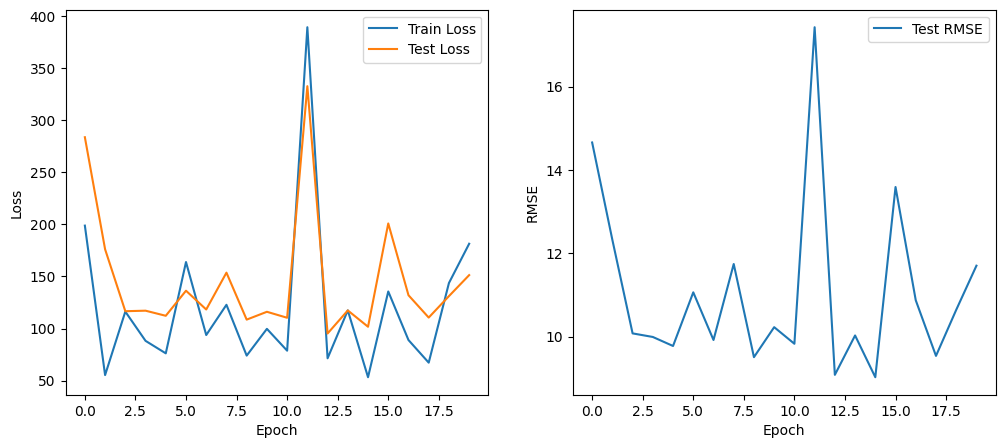

In [48]:
# Реализация функции train
def train(model, optimizer, criterion, train_loader, test_loader, epochs=10):
    train_losses = []
    test_losses = []
    test_metrics = []

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

        # Оценка на тестовой выборке
        model.eval()
        with torch.no_grad():
            test_loss = 0
            test_rmse = 0
            for X_batch, y_batch in test_loader:
                y_test_pred = model(X_batch)
                test_loss += criterion(y_test_pred, y_batch).item()
                test_rmse += torch.sqrt(criterion(y_test_pred, y_batch)).item()
            test_loss /= len(test_loader)
            test_rmse /= len(test_loader)

        train_losses.append(loss.item())
        test_losses.append(test_loss)
        test_metrics.append(test_rmse)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}, Test RMSE: {test_rmse:.4f}")

    # Графики
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(test_metrics, label="Test RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()

# Реализация функции test
def test(model, criterion, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            y_pred = model(X_batch)
            predictions.append(y_pred)
    return torch.cat(predictions).squeeze()

# Проверка формы предсказаний
assert test(model, criterion, test_loader).shape[0] == y_test.shape[0]

# Запуск обучения
train(model, optimizer, criterion, train_loader, test_loader, epochs=20)

## Задание 3. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Напишите небольшой отчет о том, как вы добились полученного качества: какие средства использовали и какие эксперименты проводили. Подробно расскажите об архитектурах и значениях гиперпараметров, а также какие метрики на тесте они показывали. Чтобы отчет был зачтен, необходимо привести хотя бы 3 эксперимента.

Отчет.

Целью эксперимента было исследовать различные подходы к решению задачи регрессии (предсказание года выпуска песни) и сравнить их эффективность. Мы провели три эксперимента:
1.	Ridge регрессия (базовый подход).
2.	Линейная регрессия с ручным обучением.
3.	Полносвязная нейронная сеть (FNN).
Эксперимент 1: Ridge регрессия
•	Описание: В качестве базового подхода использовалась Ridge регрессия из библиотеки sklearn. Ridge регрессия добавляет L2-регуляризацию к функции потерь, что помогает избежать переобучения.
•	Гиперпараметры:
o	alpha=1.0 (коэффициент регуляризации).
o	Данные были масштабированы с помощью StandardScaler.
•	Результаты:
o	RMSE на тестовой выборке: 9.51.
o	RMSE для константного прогноза (среднее значение): 10.86.
•	Анализ:
o	Ridge регрессия показала себя лучше, чем константный прогноз, что говорит о наличии полезной информации в признаках.
o	Однако качество модели все еще далеко от идеального, что указывает на необходимость более сложных моделей.

Эксперимент в задании 1: Линейная регрессия с ручным обучением
•	Описание: Реализована линейная регрессия с одним Linear слоем. Обучение проводилось вручную, без использования готовых оптимизаторов и loss-функций из PyTorch.
•	Гиперпараметры:
o	learning_rate = 0.01.
o	epochs = 10.
o	Функция потерь: MSE (среднеквадратичная ошибка), вычисленная вручную.
•	Результаты:
o	Train Loss: Уменьшился с 3,993,578.50 до 2,776,104.00.
o	Test Loss: Уменьшился с 3,835,850.75 до 2,666,435.25.
o	Test RMSE: Уменьшился с 1958.53 до 1632.92.
•	Анализ:
o	Модель обучается, но значения потерь и RMSE остаются крайне высокими.
o	Это может быть связано с недостаточной сложностью модели (линейная регрессия не может уловить сложные зависимости в данных).
o	Также возможно, что learning rate был выбран неоптимально.

Эксперимент в задании 2: Полносвязная нейронная сеть (FNN)
•	Описание: Реализована полносвязная нейронная сеть с двумя скрытыми слоями. Использовались готовые оптимизаторы и функции потерь из PyTorch.
•	Архитектура:
o	Linear(128) -> ReLU -> Linear(64) -> ReLU -> Linear(1).
•	Гиперпараметры:
o	learning_rate = 0.001.
o	epochs = 20.
o	Оптимизатор: Adam.
o	Функция потерь: MSELoss.
•	Результаты:
o	Train Loss: Колеблется между 50 и 400.
o	Test Loss: Колеблется между 95 и 330.
o	Test RMSE: Колеблется между 9.08 и 17.43.
o	Лучший RMSE: 9.08 (на 13-й эпохе).
•	Анализ:
o	Нейронная сеть показала значительно лучшее качество, чем линейная регрессия.
o	Однако наблюдается нестабильность в обучении: потери и RMSE сильно колеблются между эпохами.
o	Это может быть связано с:
	Слишком большим learning rate.
	Отсутствием регуляризации (например, Dropout).
	Недостаточным количеством данных для обучения.

Сравнение результатов
Метод	Лучший RMSE
Ridge регрессия	9.51
Линейная регрессия (ручная)	1632.92
Полносвязная нейронная сеть	9.08
•	Ridge регрессия показала себя лучше, чем константный прогноз, но хуже, чем нейронная сеть.
•	Линейная регрессия с ручным обучением оказалась неэффективной из-за недостаточной сложности модели.
•	Нейронная сеть достигла наилучшего результата (RMSE ≈ 9.08), но требует доработки для стабилизации обучения.

Выводы
1.	Нейронная сеть показала себя лучше, чем линейные модели, что подтверждает ее способность улавливать сложные зависимости в данных.
2.	Проблемы:
o	Нестабильность обучения нейронной сети (сильные колебания потерь и RMSE).
o	Высокие значения потерь и RMSE для линейной регрессии.
3.	Рекомендации:
o	Для нейронной сети:
	Уменьшить learning rate.
	Добавить регуляризацию (например, Dropout).
	Увеличить количество эпох или использовать раннюю остановку.
o	Для линейной регрессии:
	Попробовать более сложные модели (например, полиномиальную регрессию).
	Оптимизировать learning rate.
